# SR3 RV Lab — Framework 5: the meeting lattice (curve-implied vs listed digitals)

**RV class: D / B — what the options know that the curve does not.**

This is the one framework where the comparison is genuinely between the two
markets rather than between an option surface and itself.

1. From the **futures strip alone**, least-squares solve a per-meeting jump for
   every FOMC date, using the exact day-weight matrix (SR3 settles on the
   day-weighted average of its reference quarter, so a meeting inside the
   quarter counts fractionally — a Dec-9 hike moves a Dec contract by roughly a
   sixth of its size, not by 25bp).
2. Turn each jump into the FedWatch two-point lattice (`mantissa_probs`), couple
   the meetings **independently**, and day-weight them into each contract's
   settlement. That gives `P_null(rate >= K)` — a distribution that reproduces
   the futures market by construction and contains no option information.
3. Compare with the **listed** `P(rate >= K)` read off the traded vertical.

The gap is the price of everything the null throws away: marginal shape, tails,
non-25bp outcomes, intermeeting risk and meeting-to-meeting coupling. It is a
risk premium, so its *level* is not a trade — its **deviation from its own
history** is what gets tested here, and the trade is the listed vertical.

In [1]:
CONFIG = dict(
    offsets_bp=(-25.0, 0.0, 25.0),   # strikes relative to each contract's forward
    strike_tol=0.10,
    min_oi=100,
    min_tte=0.15,
    contracts_per_leg=100,
    cost_bp=1.5,                      # 2 option legs -> a vertical is cheap
    mas=(1, 5, 10),
    zscore_windows=(60, 120),
    entry_zs=(1.0, 1.5, 2.0),
    exits=("t5", "t10", "z0"),
    directions=("fade", "momentum"),
)
CONFIG

{'offsets_bp': (-25.0, 0.0, 25.0),
 'strike_tol': 0.1,
 'min_oi': 100,
 'min_tte': 0.15,
 'contracts_per_leg': 100,
 'cost_bp': 1.5,
 'mas': (1, 5, 10),
 'zscore_windows': (60, 120),
 'entry_zs': (1.0, 1.5, 2.0),
 'exits': ('t5', 't10', 'z0'),
 'directions': ('fade', 'momentum')}

In [2]:
import datetime
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sfr_rv_lab_common import LabConfig, load_lab, run_framework
from RVUtils.SFRRVLab import (
    FOMC_DATES, Leg, Structure, add_event_distance, constant_maturity_slots,
    quarterly_sort_key, vertical_digital,
)
from RVUtils.SFRRVLab.lattice import (
    day_weight_matrix, meeting_null_distribution, null_prob_ge,
    solve_meeting_jumps,
)
from RVUtils.SFRRVLab.signals import digital_legs
from MDP.STIRFutures._sofr_option_contracts import quarterly_reference_window

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

lab = load_lab()
quotes, contracts = lab["quotes"], lab["contracts"]
# `contracts` already carries tte from the panel builder; only the slot is new
contracts = contracts.merge(
    constant_maturity_slots(contracts)[["as_of", "symbol", "cm_slot"]],
    on=["as_of", "symbol"], how="left")

WINDOWS = {s: quarterly_reference_window(s)
           for s in sorted(contracts["symbol"].unique(), key=quarterly_sort_key)}
for s, w in WINDOWS.items():
    print(f"  {s}: reference quarter {w[0]} .. {w[1]}")

parity completion: 199319 listed quotes + 191259 reconstructed (96.0%) so ITM legs stay marked


  SFRH25: reference quarter 2025-03-19 .. 2025-06-18
  SFRM25: reference quarter 2025-06-18 .. 2025-09-17
  SFRU25: reference quarter 2025-09-17 .. 2025-12-17
  SFRZ25: reference quarter 2025-12-17 .. 2026-03-18
  SFRH26: reference quarter 2026-03-18 .. 2026-06-17
  SFRM26: reference quarter 2026-06-17 .. 2026-09-16
  SFRU26: reference quarter 2026-09-16 .. 2026-12-16
  SFRZ26: reference quarter 2026-12-16 .. 2027-03-17
  SFRH27: reference quarter 2027-03-17 .. 2027-06-16
  SFRM27: reference quarter 2027-06-16 .. 2027-09-15
  SFRU27: reference quarter 2027-09-15 .. 2027-12-15
  SFRZ27: reference quarter 2027-12-15 .. 2028-03-15
  SFRH28: reference quarter 2028-03-15 .. 2028-06-21
  SFRM28: reference quarter 2028-06-21 .. 2028-09-20


## Step 1-2 — the curve-only null, per date

The base rate is the front contract's own forward: with the front quarter
largely already fixed, it anchors the level the meeting jumps move away from.

In [3]:
fwd = contracts.set_index(["as_of", "symbol"])["forward_rate"]
fwd_px = contracts.set_index(["as_of", "symbol"])["forward_price"]
QDAY = {k: v for k, v in quotes.groupby(["as_of", "symbol"], sort=False)}

rows = []
for ts, day in contracts.groupby("as_of"):
    day = day[day["tte"] >= CONFIG["min_tte"]].sort_values("expiry_date")
    syms = [s for s in day["symbol"] if s in WINDOWS]
    if len(syms) < 3:
        continue
    wins = [WINDOWS[s] for s in syms]
    d0 = ts.date()
    meetings = [m for m in FOMC_DATES if d0 < m <= max(w[1] for w in wins)]
    if not meetings:
        continue
    W = day_weight_matrix(wins, meetings)
    fwd_bp = np.array([float(fwd[(ts, s)]) * 100.0 for s in syms])
    base_bp = float(fwd_bp[0])
    jumps = solve_meeting_jumps(fwd_bp, W, base_bp)
    for i, sym in enumerate(syms):
        off, p = meeting_null_distribution(jumps, W[i], merge_bp=0.5)
        g = QDAY.get((ts, sym))
        if g is None:
            continue
        if CONFIG["min_oi"] > 0:
            g = g[g["oi"] >= CONFIG["min_oi"]]
        f_rate = float(fwd[(ts, sym)])
        f_px = float(fwd_px[(ts, sym)])
        for o in CONFIG["offsets_bp"]:
            k_rate = f_rate + o / 100.0
            d = vertical_digital(g, k_rate, tol=CONFIG["strike_tol"],
                                 forward_price=f_px)
            if d is None:
                continue
            p_null = null_prob_ge(off, p, base_bp, k_rate * 100.0)
            rows.append({
                "as_of": ts, "symbol": sym, "offset_bp": o,
                "key": f"{sym}@{o:+.0f}",
                "p_listed": d["prob"], "p_null": p_null,
                "signal": d["prob"] - p_null,
                "k_lo": d["k_lo"], "k_hi": d["k_hi"], "right": d["right"],
                "n_meetings": len(meetings), "gate": True,
            })
lat = pd.DataFrame(rows)
print(f"\nlattice panel (raw): {len(lat)} rows")

# Hygiene: a normalised vertical is a probability. Values outside [0, 1] mean a
# stale settle or a bracket that straddles the OTM boundary with mismatched
# widths — not information. Drop them and say how many.
if len(lat):
    bad = ~lat["p_listed"].between(-0.02, 1.02)
    print(f"dropping {int(bad.sum())} rows ({bad.mean():.2%}) whose listed "
          f"vertical implies a probability outside [0, 1]")
    lat = lat[~bad].copy()
print(f"lattice panel: {len(lat)} rows, {lat['key'].nunique() if len(lat) else 0} keys")
if len(lat):
    lat = add_event_distance(lat)
    print(lat.groupby("offset_bp")[["p_listed", "p_null", "signal"]]
          .describe().round(3).to_string())


lattice panel (raw): 11113 rows
dropping 3 rows (0.03%) whose listed vertical implies a probability outside [0, 1]
lattice panel: 11110 rows, 42 keys
          p_listed                                              p_null                                                   signal                                                 
             count   mean    std   min   25%   50%   75%   max   count   mean    std    min    25%    50%    75%    max   count   mean    std    min    25%    50%    75%    max
offset_bp                                                                                                                                                                       
-25.0       3698.0  0.687  0.089  0.54  0.62  0.66  0.72  1.00  3698.0  0.856  0.091  0.615  0.785  0.848  0.922  1.000  3698.0 -0.169  0.080 -0.411 -0.222 -0.160 -0.110  0.035
 0.0        3673.0  0.540  0.068  0.24  0.50  0.54  0.60  0.80  3673.0  0.541  0.144  0.032  0.439  0.513  0.607  0.999  3673.0 -0.000  0.153

### The gap is a premium, not an arbitrage

If the options systematically price more tail than the two-point lattice, the
gap has a persistent sign. That level is the price of the information the null
discards; only the deviation from it is a candidate trade.

mean gap (listed - null) by strike offset:
             mean     std  count
offset_bp                       
-25.0     -0.1686  0.0803   3698
 0.0      -0.0002  0.1534   3673
 25.0      0.2126  0.1025   3739

How much of the gap's VARIATION is the options side rather than the null? If the null is near-degenerate at a strike, the 'gap' signal is just the listed digital wearing a different name:
           p_listed  p_null
offset_bp                  
-25.0        0.0889  0.0915
 0.0         0.0682  0.1442
 25.0        0.0991  0.0934


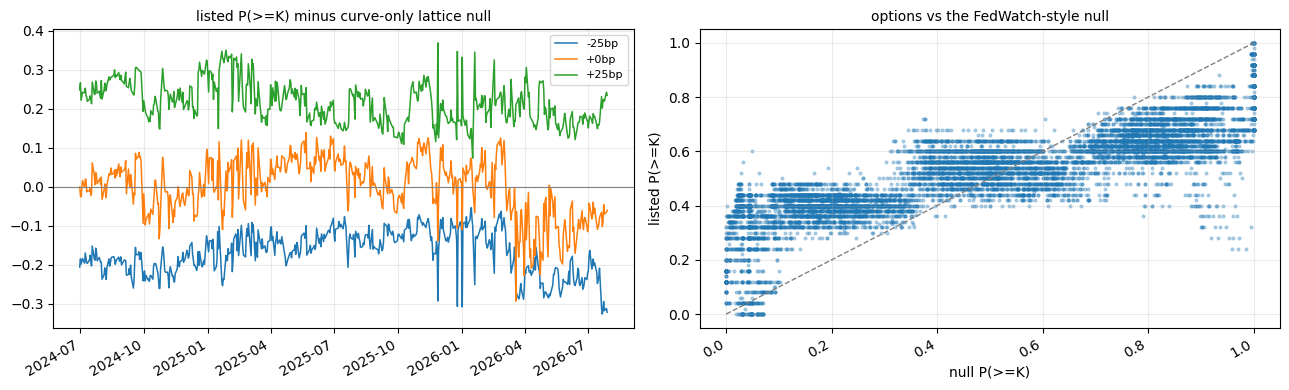

In [4]:
if len(lat):
    print("mean gap (listed - null) by strike offset:")
    print(lat.groupby("offset_bp")["signal"].agg(["mean", "std", "count"])
          .round(4).to_string())
    print("\nHow much of the gap's VARIATION is the options side rather than the "
          "null? If the null is near-degenerate at a strike, the 'gap' signal is "
          "just the listed digital wearing a different name:")
    print(lat.groupby("offset_bp")[["p_listed", "p_null"]].std().round(4).to_string())
    from sfr_rv_lab_common import DATA_DIR as _DD
    (lat.groupby("offset_bp")
     .agg(mean_listed=("p_listed", "mean"), mean_null=("p_null", "mean"),
          mean_gap=("signal", "mean"), sd_gap=("signal", "std"),
          sd_listed=("p_listed", "std"), sd_null=("p_null", "std"),
          n=("signal", "size"))
     .round(4).to_csv(_DD / "lattice_gap.csv"))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for o, sub in lat.groupby("offset_bp"):
        s = sub.groupby("as_of")["signal"].mean()
        axes[0].plot(s.index, s.to_numpy(), lw=1.1, label=f"{o:+.0f}bp")
    axes[0].axhline(0, color="grey", lw=0.8)
    axes[0].legend(fontsize=8)
    axes[0].set_title("listed P(>=K) minus curve-only lattice null", fontsize=10)
    axes[0].grid(alpha=0.25)
    axes[1].scatter(lat["p_null"], lat["p_listed"], s=4, alpha=0.3)
    axes[1].plot([0, 1], [0, 1], color="grey", ls="--", lw=1)
    axes[1].set_xlabel("null P(>=K)")
    axes[1].set_ylabel("listed P(>=K)")
    axes[1].set_title("options vs the FedWatch-style null", fontsize=10)
    axes[1].grid(alpha=0.25)
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

## Step 3 — trade the deviation, as the listed vertical

  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs



=== 5. Meeting lattice (listed vs FedWatch null) — grid ===
  108 configs | median -751.61bp | IQR [-991.19, -473.30] | 0% net-positive | best -206.53bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
     fade  10             60               2.0         z0       174     0.379      -1.187      -206.526     -516314.25  -1.378   -240.432
     fade  10             60               2.0        t10       207     0.362      -1.288      -266.531     -666327.25  -2.096   -275.801
     fade  10            120               2.0         z0       160     0.319      -1.848      -295.686     -739215.00  -1.839   -314.780
 momentum  10            120               2.0         z0       160     0.256      -1.883      -301.356     -753391.25  -1.876   -299.635
 momentum   5            120               2.0         z0       203     0.296      -1.

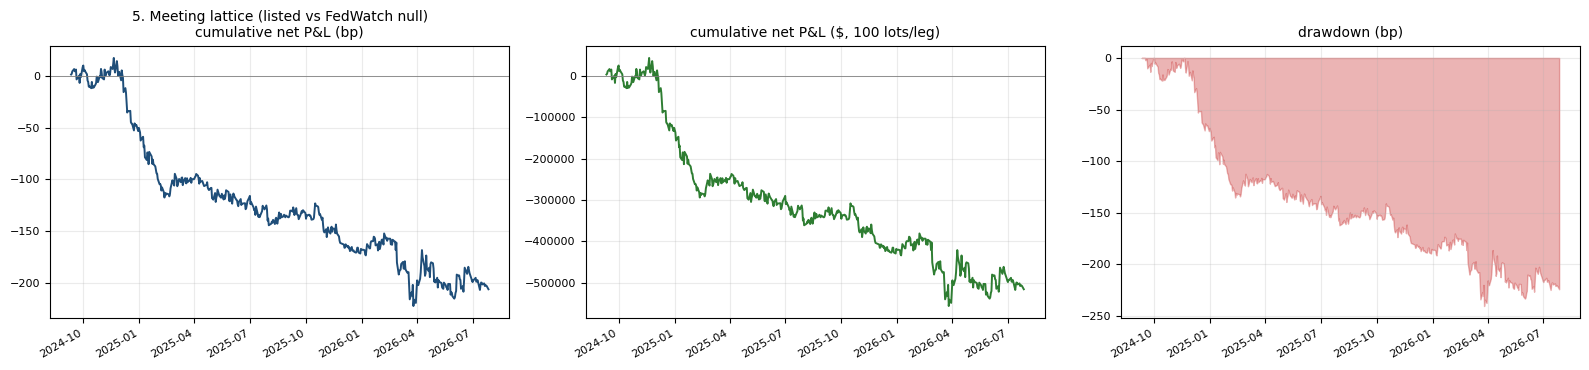


TRADE LOG (first rows)
       key  dir          structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp   net_bp   net_usd  stale_frac  pkg_contracts    exit_reason
SFRM25@+25   -1 digital SFRM25@+25  2024-09-09 2024-09-10 2024-10-01    15  2.423    5.4298      1.5   3.9298   9824.61         0.0           32.0 mean_reversion
SFRM25@-25   -1 digital SFRM25@-25  2024-09-10 2024-09-11 2024-10-04    17  2.141    5.0951      1.5   3.5951   8987.76         0.0           32.0 mean_reversion
SFRU25@-25    1 digital SFRU25@-25  2024-09-12 2024-09-13 2024-10-11    20 -2.390    0.3807      1.5  -1.1193  -2798.23         0.0           16.0       max_hold
 SFRH25@+0   -1  digital SFRH25@+0  2024-09-13 2024-09-16 2024-10-08    16  2.353    5.2633      1.5   3.7633   9408.36         0.0           32.0 mean_reversion
 SFRZ25@+0    1  digital SFRZ25@+0  2024-09-17 2024-09-18 2024-09-20     2 -2.779   -1.4554      1.5  -2.9554  -7388.60         0.0           16.0 mean_reversion
SFRZ

exit  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp  avg_hold_days
  z0       174     0.379      -1.187      -206.526     -516314.25  -1.378   -240.432         15.782
half       174     0.391      -1.220      -212.337     -530841.50  -1.449   -237.384         14.448
  t5       279     0.280      -1.590      -443.589    -1108973.00  -3.958   -450.469          4.921
 t10       207     0.362      -1.288      -266.531     -666327.25  -2.096   -275.801          9.749
 t20       162     0.370      -1.303      -211.160     -527899.50  -1.366   -235.214         19.117

MARKS x LAG


signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0       176           1.757      -262.243  -1.442     0.381
       listed    1       174          54.474      -206.526  -1.378     0.379
same-bar (lag 0) gross inflation: -2999.7%

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 174        54.474       0.313     0.540      136185.75
           0.5 174       -32.526      -0.187     0.489      -81314.25
           1.0 174      -119.526      -0.687     0.431     -298814.25
           1.5 174      -206.526      -1.187     0.379     -516314.25
           2.5 174      -380.526      -2.187     0.253     -951314.25
           4.0 174      -641.526      -3.687     0.144    -1603814.25

5. Meeting lattice (listed vs FedWatch null) — median config (not selected)  |  momentum|ma5|w60|z1.5|z0|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 16 contracts 

In [5]:
LAT_IDX = lat.set_index(["key", "as_of"]).sort_index() if len(lat) else None


def builder(key, exec_date, direction):
    try:
        r = LAT_IDX.loc[(key, exec_date)]
    except (KeyError, AttributeError):
        return None
    if isinstance(r, pd.DataFrame):
        r = r.iloc[0]
    sym = key.split("@")[0]
    return Structure(digital_legs(sym, float(r["k_lo"]), float(r["k_hi"]),
                                  str(r["right"]), weight=1.0),
                     label=f"digital {key}")


BASE = LabConfig(lag=1, round_trip_cost_bp=CONFIG["cost_bp"],
                 contracts_per_leg=CONFIG["contracts_per_leg"],
                 delta_hedge="daily", future_leg_bp=0.25)
GRID = {"direction": list(CONFIG["directions"]), "ma": list(CONFIG["mas"]),
        "zscore_window": list(CONFIG["zscore_windows"]),
        "entry_min_zscore": list(CONFIG["entry_zs"]),
        "exit_style": list(CONFIG["exits"])}
PARAMS = ["direction", "ma", "zscore_window", "entry_min_zscore", "exit_style"]

if len(lat):
    out = run_framework(
        "5. Meeting lattice (listed vs FedWatch null)", signals=lat,
        book=lab["book"], builder=builder, base=BASE, grid_spec=GRID,
        params=PARAMS, cls="D/B",
        note="listed vertical, delta-hedged daily; null solved from the strip")

## FOMC-window variant

The null is a *meeting* model, so if it carries information at all it should
carry it around meetings.

eligible bars: 15.6%



=== 5b. Meeting lattice (FOMC window) — grid ===
  16 configs | median -325.60bp | IQR [-389.69, -258.10] | 0% net-positive | best -172.98bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
 momentum   1               1.5        t10       154     0.299      -1.123      -172.976     -432441.00  -1.619   -208.611
 momentum   1               1.5         t5       154     0.318      -1.326      -204.148     -510370.25  -3.108   -217.822
 momentum   5               1.5         t5       144     0.285      -1.550      -223.136     -557840.00  -3.854   -240.025
 momentum   5               1.5        t10       144     0.243      -1.595      -229.658     -574146.00  -2.634   -244.682
     fade   5               1.5         t5       144     0.243      -1.858      -267.580     -668950.50  -5.043   -270.825
     fade   5               1.5        t10       1

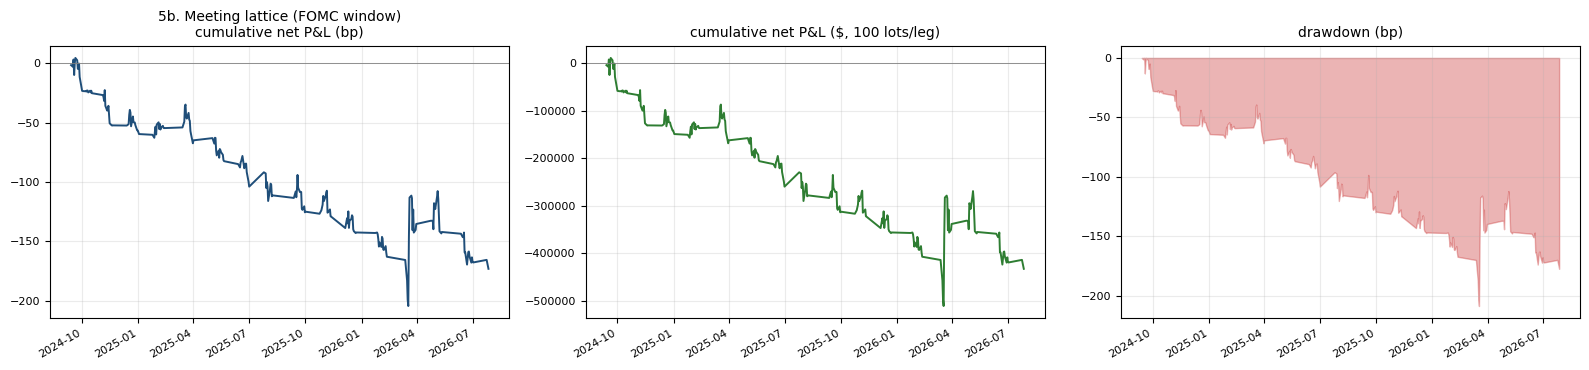


EXIT COMPARISON


exit  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp  avg_hold_days
  z0       160     0.288      -1.876      -300.223     -750556.75  -2.614   -300.824          8.781
half       157     0.236      -2.057      -322.958     -807394.25  -3.090   -321.245          8.885
  t5       154     0.318      -1.326      -204.148     -510370.25  -3.108   -217.822          4.877
 t10       154     0.299      -1.123      -172.976     -432441.00  -1.619   -208.611          9.714
 t20       154     0.318      -2.042      -314.536     -786339.75  -1.717   -325.301         19.390

MARKS x LAG


signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0       154         -79.443      -310.443  -2.411     0.234
       listed    1       154          58.024      -172.976  -1.619     0.299
same-bar (lag 0) gross inflation: 173.0%

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 154        58.024       0.377     0.545       145059.0
           0.5 154       -18.976      -0.123     0.494       -47441.0
           1.0 154       -95.976      -0.623     0.370      -239941.0
           1.5 154      -172.976      -1.123     0.299      -432441.0
           2.5 154      -326.976      -2.123     0.221      -817441.0
           4.0 154      -557.976      -3.623     0.136     -1394941.0

5b. Meeting lattice (FOMC window) — median config (not selected)  |  momentum|ma5|w120|z1.0|t5|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 16 contracts -> position 

In [6]:
if len(lat):
    ev = lat.copy()
    ev["eligible"] = ev["days_to_fomc"].between(-7, -1)
    print(f"eligible bars: {ev['eligible'].mean():.1%}")
    out_ev = run_framework(
        "5b. Meeting lattice (FOMC window)", signals=ev, book=lab["book"],
        builder=builder, base=BASE,
        grid_spec={"direction": list(CONFIG["directions"]), "ma": [1, 5],
                   "entry_min_zscore": [1.0, 1.5], "exit_style": ["t5", "t10"]},
        params=["direction", "ma", "entry_min_zscore", "exit_style"], cls="D/B",
        note="entries limited to 7 business days pre-FOMC", show_trades=0)